In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('features_v3.csv')

X = df.drop(columns='user')


In [3]:
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


In [4]:
l        = pd.read_csv('cert_dataset/insiders/insiders.csv')
INSIDERS = l[l['dataset'] == 6.2]['user']


In [5]:
X_train        = X_scaled[~df['user'].isin(INSIDERS)]
X_tensor_train = torch.FloatTensor(X_train.values)

X_tensor_all   = torch.FloatTensor(X_scaled.values)

dataset = TensorDataset(X_tensor_train)
loader  = DataLoader(dataset, batch_size=256, shuffle=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_51084\3934269976.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_tensor_train = torch.FloatTensor(X_train.values)


In [6]:
class Autoencoder(nn.Module):
    def __init__(self, n_features, latent_dim=8):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(n_features, 38),
            nn.BatchNorm1d(38),
            nn.ReLU(),
            nn.Linear(38, 26),
            nn.BatchNorm1d(26),
            nn.ReLU(),
            nn.Linear(26, 18),
            nn.BatchNorm1d(18),
            nn.ReLU(),
            nn.Linear(18, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 18),
            nn.BatchNorm1d(18),
            nn.ReLU(),
            nn.Linear(18, 26),
            nn.BatchNorm1d(26),
            nn.ReLU(),
            nn.Linear(26, 38),
            nn.BatchNorm1d(38),
            nn.ReLU(),
            nn.Linear(38, n_features),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [7]:
class AutoencoderSkip(nn.Module):
    def __init__(self, n_features, latent_dim=8):
        super().__init__()

        self.enc1 = nn.Sequential(nn.Linear(n_features, 38), nn.BatchNorm1d(38), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Linear(38, 26),          nn.BatchNorm1d(26), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Linear(26, 18),          nn.BatchNorm1d(18), nn.ReLU())
        self.enc4 = nn.Linear(18, latent_dim)

        self.dec1 = nn.Sequential(nn.Linear(latent_dim, 18),  nn.BatchNorm1d(18), nn.ReLU())
        self.dec2 = nn.Sequential(nn.Linear(18 + 26, 26),     nn.BatchNorm1d(26), nn.ReLU())
        self.dec3 = nn.Sequential(nn.Linear(26 + 38, 38),     nn.BatchNorm1d(38), nn.ReLU())
        self.dec4 = nn.Linear(38, n_features)

    def forward(self, x):
        h1    = self.enc1(x)
        h2    = self.enc2(h1)
        h3    = self.enc3(h2)
        z     = self.enc4(h3)

        d1    = self.dec1(z)
        d2    = self.dec2(torch.cat([d1, h2], dim=1))
        d3    = self.dec3(torch.cat([d2, h1], dim=1))
        x_hat = self.dec4(d3)

        return x_hat


In [8]:
def train_model(model, loader, n_epochs=1000, lr=1e-3, weight_decay=1e-4, label=''):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_loss  = float('inf')
    best_state = None

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for (batch,) in loader:
            reconstructed = model(batch)
            loss = criterion(reconstructed, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)

        if avg_loss < best_loss:
            best_loss  = avg_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f"[{label}] Epoch {epoch} — Loss: {avg_loss:.4f}")

    model.load_state_dict(best_state)
    return model


In [9]:
n_features = X_scaled.shape[1]

model_ae   = Autoencoder(n_features=n_features)
model_skip = AutoencoderSkip(n_features=n_features)

print("=== Entraînement Autoencoder ===")
model_ae   = train_model(model_ae,   loader, label='AE')

print("\n=== Entraînement AutoencoderSkip ===")
model_skip = train_model(model_skip, loader, label='AESkip')


=== Entraînement Autoencoder ===
[AE] Epoch 0 — Loss: 1.0379
[AE] Epoch 20 — Loss: 0.3873
[AE] Epoch 40 — Loss: 0.3142
[AE] Epoch 60 — Loss: 0.2885
[AE] Epoch 80 — Loss: 0.2633
[AE] Epoch 100 — Loss: 0.2489
[AE] Epoch 120 — Loss: 0.2396
[AE] Epoch 140 — Loss: 0.2293
[AE] Epoch 160 — Loss: 0.2234
[AE] Epoch 180 — Loss: 0.2218
[AE] Epoch 200 — Loss: 0.2124
[AE] Epoch 220 — Loss: 0.2131
[AE] Epoch 240 — Loss: 0.2057
[AE] Epoch 260 — Loss: 0.2068
[AE] Epoch 280 — Loss: 0.2005
[AE] Epoch 300 — Loss: 0.1987
[AE] Epoch 320 — Loss: 0.1962
[AE] Epoch 340 — Loss: 0.1916
[AE] Epoch 360 — Loss: 0.1928
[AE] Epoch 380 — Loss: 0.1906
[AE] Epoch 400 — Loss: 0.1861
[AE] Epoch 420 — Loss: 0.1901
[AE] Epoch 440 — Loss: 0.1873
[AE] Epoch 460 — Loss: 0.1817
[AE] Epoch 480 — Loss: 0.1796
[AE] Epoch 500 — Loss: 0.1784
[AE] Epoch 520 — Loss: 0.1778
[AE] Epoch 540 — Loss: 0.1805
[AE] Epoch 560 — Loss: 0.1774
[AE] Epoch 580 — Loss: 0.1792
[AE] Epoch 600 — Loss: 0.1726
[AE] Epoch 620 — Loss: 0.1763
[AE] Epoch 64

In [10]:
model_ae.eval()
model_skip.eval()

with torch.no_grad():
    recon_ae    = model_ae(X_tensor_all)
    errors_ae   = torch.mean((X_tensor_all - recon_ae) ** 2, dim=1).numpy()

    recon_skip  = model_skip(X_tensor_all)
    errors_skip = torch.mean((X_tensor_all - recon_skip) ** 2, dim=1).numpy()


In [45]:

def minmax_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

errors_ae_norm   = minmax_norm(errors_ae)
errors_skip_norm = minmax_norm(errors_skip)


w_ae   = 0.48
w_skip = 0.52
errors_ensemble = w_ae * errors_ae_norm + w_skip * errors_skip_norm


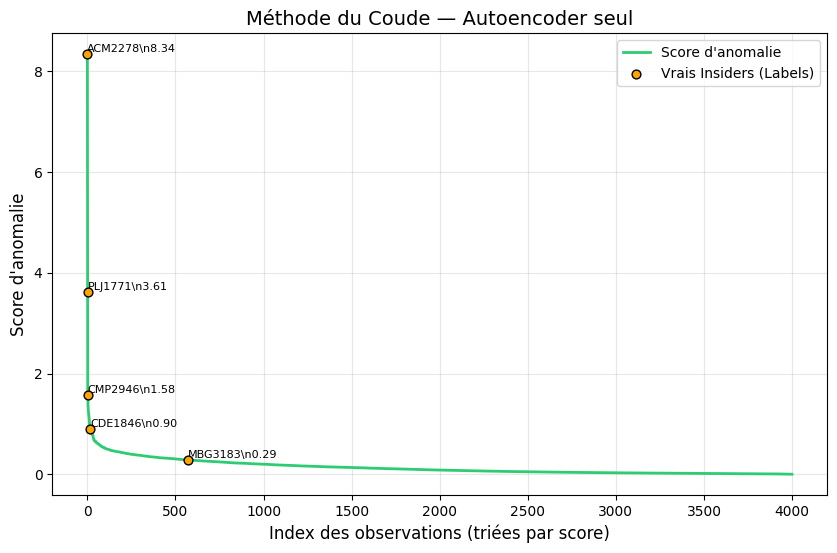

Ranking des insiders (Autoencoder seul) :
         user     score  rank
64    ACM2278  8.338971     1
2987  PLJ1771  3.614368     2
815   CMP2946  1.579381     3
676   CDE1846  0.900505    17
2488  MBG3183  0.289629   570

Top-5 hit rate : 3 / 5
Mean rank       : 118.6 / 4000


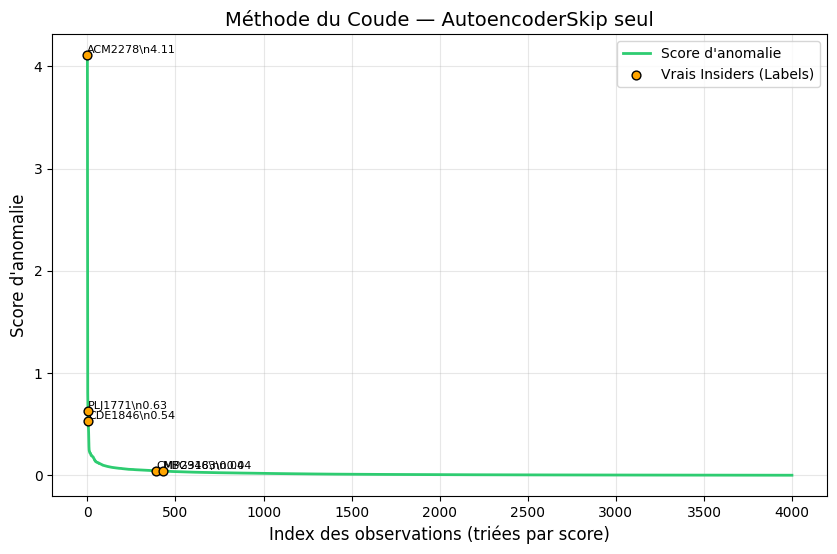

Ranking des insiders (AutoencoderSkip seul) :
         user     score  rank
64    ACM2278  4.108928     1
2987  PLJ1771  0.630100     4
676   CDE1846  0.535498     5
815   CMP2946  0.043904   390
2488  MBG3183  0.041017   428

Top-5 hit rate : 3 / 5
Mean rank       : 165.6 / 4000


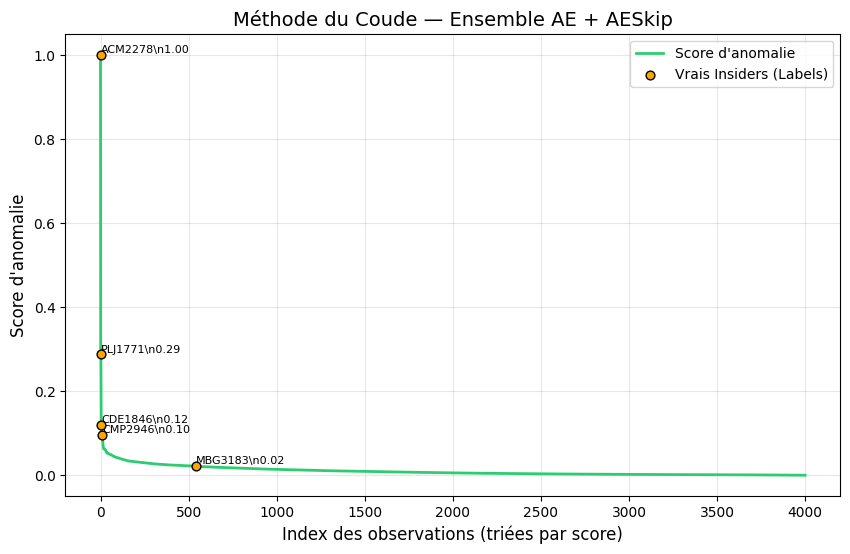

Ranking des insiders (Ensemble AE + AESkip) :
         user     score  rank
64    ACM2278  1.000000     1
2987  PLJ1771  0.287588     3
676   CDE1846  0.119327     5
815   CMP2946  0.096199     9
2488  MBG3183  0.021559   544

Top-5 hit rate : 3 / 5
Mean rank       : 112.4 / 4000

  Récap : AE=3/5  |  AESkip=3/5  |  Ensemble=3/5


In [46]:
K = 5

def show_ranking(scores, users, insiders, label):
    users_arr = np.asarray(users, dtype=str)
    insiders_arr = np.asarray(insiders, dtype=str)

    df_scores = pd.DataFrame({'user': users_arr, 'score': scores})
    df_scores = df_scores.sort_values('score', ascending=False)
    df_scores['rank'] = range(1, len(df_scores) + 1)

    sorted_indices = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_indices]
    sorted_users = users_arr[sorted_indices]
    sorted_insiders = np.isin(sorted_users, insiders_arr).astype(int)
    insider_plot_indices = np.where(sorted_insiders == 1)[0]

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(sorted_scores)), sorted_scores, label="Score d'anomalie", color='#2ecc71', linewidth=2)
    plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices],
                color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')
    for i in insider_plot_indices:
        plt.text(i, sorted_scores[i], f"{sorted_users[i]}\\n{sorted_scores[i]:.2f}",
                 fontsize=8, ha='left', va='bottom')
    plt.title(f"Méthode du Coude — {label}", fontsize=14)
    plt.xlabel("Index des observations (triées par score)", fontsize=12)
    plt.ylabel("Score d'anomalie", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Ranking des insiders ({label}) :")
    print(df_scores[df_scores['user'].isin(insiders_arr)][['user', 'score', 'rank']])
    hits = (df_scores[df_scores['user'].isin(insiders_arr)]['rank'] <= K).sum()
    print(f"\nTop-{K} hit rate : {hits} / {len(insiders_arr)}")
    mean_rank = df_scores[df_scores['user'].isin(insiders_arr)]['rank'].mean()
    print(f"Mean rank       : {mean_rank:.1f} / {len(df_scores)}")
    return hits

users = df['user'].astype(str).to_numpy()

hits_ae       = show_ranking(errors_ae,       users, INSIDERS, 'Autoencoder seul')
hits_skip     = show_ranking(errors_skip,     users, INSIDERS, 'AutoencoderSkip seul')
hits_ensemble = show_ranking(errors_ensemble, users, INSIDERS, 'Ensemble AE + AESkip')

print(f"\n{'='*50}")
print(f"  Récap : AE={hits_ae}/5  |  AESkip={hits_skip}/5  |  Ensemble={hits_ensemble}/5")
print(f"{'='*50}")

### Avec gridSearch


Grid search terminé — 201 combinaisons testées
Meilleurs poids  : w_ae=0.245  |  w_skip=0.755
Mean rank obtenu : 99.4  |  Top-5 hits : 3


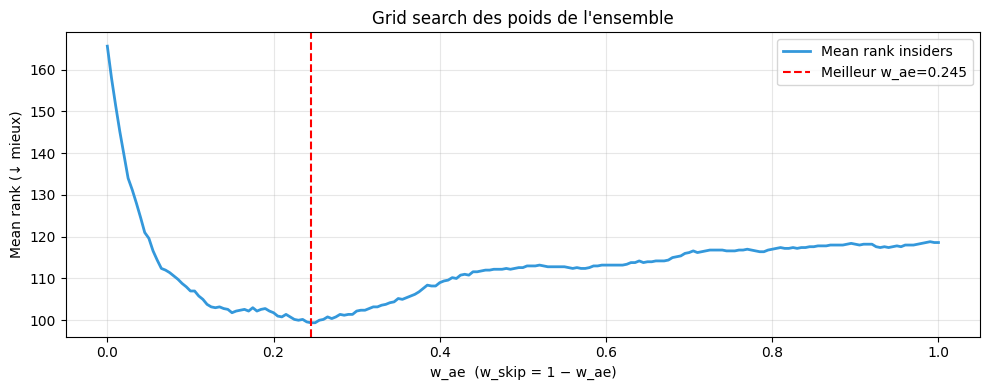

In [24]:
users_arr    = np.asarray(df['user'], dtype=str)
insiders_arr = np.asarray(INSIDERS,   dtype=str)

def score_weights(w_ae, w_skip):
    """Retourne (mean_rank, -hits) pour un couple de poids donné."""
    ens    = w_ae * errors_ae_norm + w_skip * errors_skip_norm
    order  = np.argsort(ens)[::-1]
    ranked = users_arr[order]
    ranks  = {u: r+1 for r, u in enumerate(ranked)}
    insider_ranks = [ranks[u] for u in insiders_arr if u in ranks]
    if not insider_ranks:
        return float('inf'), 0
    K_local = 5
    hits      = sum(r <= K_local for r in insider_ranks)
    mean_rank = np.mean(insider_ranks)
    return mean_rank, -hits


grid        = np.linspace(0, 1, 201)
best_score  = (float('inf'), 0)
best_w_ae   = 0.5
results     = []

for w in grid:
    mean_r, neg_hits = score_weights(w, 1 - w)
    results.append((w, mean_r, -neg_hits))
    if (mean_r, neg_hits) < best_score:
        best_score = (mean_r, neg_hits)
        best_w_ae  = w

best_w_skip = 1 - best_w_ae
print(f"Grid search terminé — {len(grid)} combinaisons testées")
print(f"Meilleurs poids  : w_ae={best_w_ae:.3f}  |  w_skip={best_w_skip:.3f}")
print(f"Mean rank obtenu : {best_score[0]:.1f}  |  Top-5 hits : {-best_score[1]}")


res_arr    = np.array(results)
plt.figure(figsize=(10, 4))
plt.plot(res_arr[:, 0], res_arr[:, 1], color='#3498db', linewidth=2, label='Mean rank insiders')
plt.axvline(best_w_ae, color='red', linestyle='--', label=f'Meilleur w_ae={best_w_ae:.3f}')
plt.xlabel('w_ae  (w_skip = 1 − w_ae)')
plt.ylabel('Mean rank (↓ mieux)')
plt.title('Grid search des poids de l\'ensemble')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


w_ae   = best_w_ae
w_skip = best_w_skip
errors_ensemble = w_ae * errors_ae_norm + w_skip * errors_skip_norm


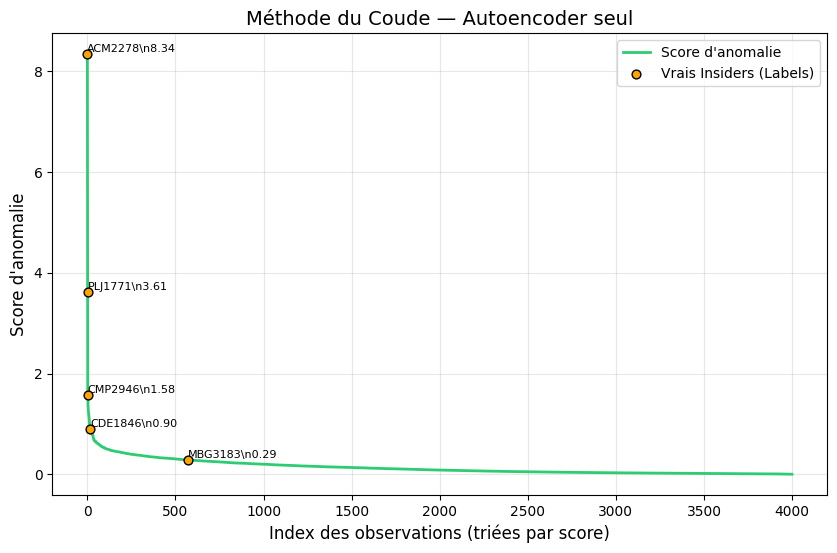

Ranking des insiders (Autoencoder seul) :
         user     score  rank
64    ACM2278  8.338971     1
2987  PLJ1771  3.614368     2
815   CMP2946  1.579381     3
676   CDE1846  0.900505    17
2488  MBG3183  0.289629   570

Top-5 hit rate : 3 / 5
Mean rank       : 118.6 / 4000


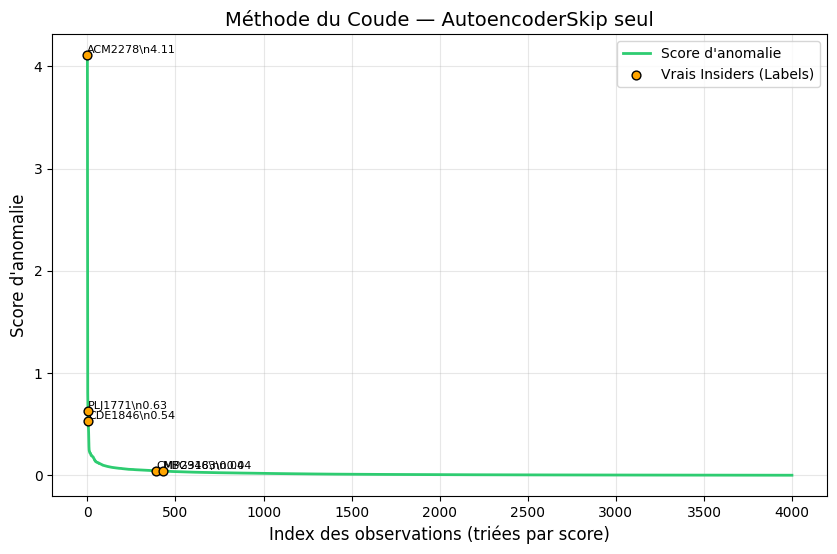

Ranking des insiders (AutoencoderSkip seul) :
         user     score  rank
64    ACM2278  4.108928     1
2987  PLJ1771  0.630100     4
676   CDE1846  0.535498     5
815   CMP2946  0.043904   390
2488  MBG3183  0.041017   428

Top-5 hit rate : 3 / 5
Mean rank       : 165.6 / 4000


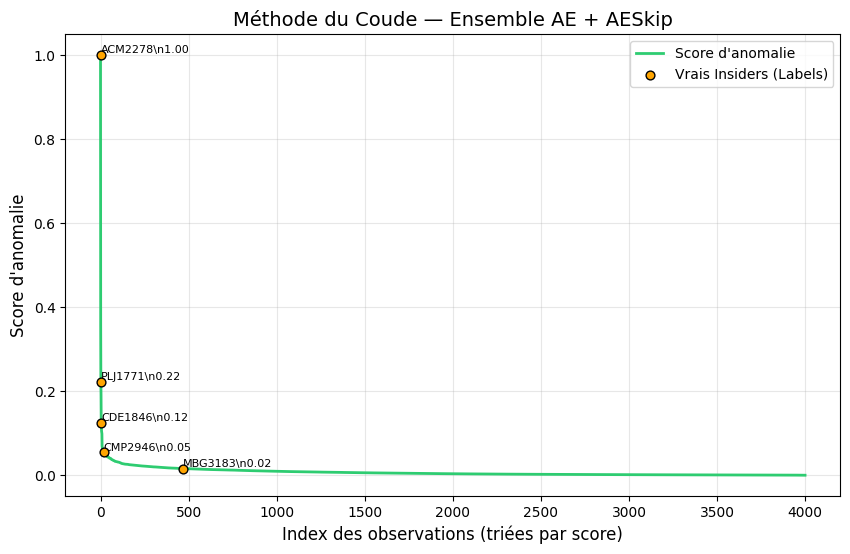

Ranking des insiders (Ensemble AE + AESkip) :
         user     score  rank
64    ACM2278  1.000000     1
2987  PLJ1771  0.221801     3
676   CDE1846  0.124644     5
815   CMP2946  0.054256    20
2488  MBG3183  0.015814   468

Top-5 hit rate : 3 / 5
Mean rank       : 99.4 / 4000

  Récap : AE=3/5  |  AESkip=3/5  |  Ensemble=3/5


In [25]:
users = df['user'].astype(str).to_numpy()

hits_ae       = show_ranking(errors_ae,       users, INSIDERS, 'Autoencoder seul')
hits_skip     = show_ranking(errors_skip,     users, INSIDERS, 'AutoencoderSkip seul')
hits_ensemble = show_ranking(errors_ensemble, users, INSIDERS, 'Ensemble AE + AESkip')

print(f"\n{'='*50}")
print(f"  Récap : AE={hits_ae}/5  |  AESkip={hits_skip}/5  |  Ensemble={hits_ensemble}/5")
print(f"{'='*50}")